In [4]:
import numpy as np
import matplotlib.pyplot as plt

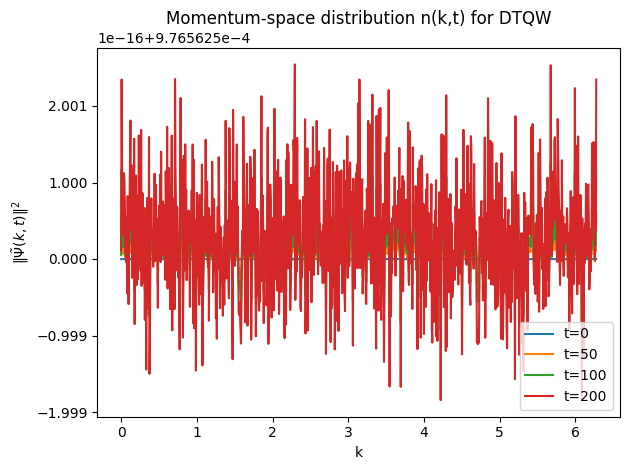

In [5]:
# -------------------- Parameters --------------------
N = 1024                    # number of sites (k-points); use power of 2 for FFT convenience
theta = np.pi / 4           # coin angle; pi/4 ~ Hadamard-like (no extra phases here)
t_list = [0, 50, 100, 200]  # times at which to compute/plot n(k,t)

# Initial coin spinor |chi> = alpha|up> + beta|down> (must be normalized)
alpha, beta = 1/np.sqrt(2), 1/np.sqrt(2)
chi = np.array([alpha, beta], dtype=complex)

# -------------------- k-grid and per-k step U(k) --------------------
# On a ring: k_m = 2π m / N, m=0..N-1
m = np.arange(N)
k = 2 * np.pi * m / N

# Coin C(θ) without extra phases (rotation in up/down basis)
C = np.array([[np.cos(theta),  np.sin(theta)],
              [-np.sin(theta), np.cos(theta)]], dtype=complex)

# Shift S(k) = diag(e^{+ik}, e^{-ik}) with convention: up→right, down→left
exp_ik  = np.exp(1j * k)
exp_mik = np.exp(-1j * k)

# Build U(k) = S(k) @ C as an array of shape (N,2,2)
U = np.zeros((N, 2, 2), dtype=complex)
U[:, 0, 0] = exp_ik * C[0, 0]
U[:, 0, 1] = exp_ik * C[0, 1]
U[:, 1, 0] = exp_mik * C[1, 0]
U[:, 1, 1] = exp_mik * C[1, 1]

# -------------------- Eigendecompose once (fast reuse for all t) --------------------
eigvals = np.zeros((N, 2), dtype=complex)
eigvecs = np.zeros((N, 2, 2), dtype=complex)
for i in range(N):
    w, v = np.linalg.eig(U[i])
    eigvals[i] = w
    eigvecs[i] = v
eigvecs_inv = np.linalg.inv(eigvecs)

def evolve_k(psi_k0, t):
    """
    Evolve Ψ̃(k,0) -> Ψ̃(k,t) using U(k)^t via eigen-decomposition:
        U^t = V diag(w^t) V^{-1}
    psi_k0: shape (N,2)
    returns psi_k_t: shape (N,2)
    """
    wt = eigvals ** t                      # (N,2)
    out = np.zeros_like(psi_k0)
    for i in range(N):
        out[i] = eigvecs[i] @ (wt[i] * (eigvecs_inv[i] @ psi_k0[i]))
    return out

# -------------------- Initial state in k-space --------------------
# Localized at x=0  => uniform over k: Ψ̃(k,0) = (1/√N) |chi>
psi_k0 = np.tile(chi, (N, 1)) / np.sqrt(N)

# -------------------- Compute n(k,t) for requested times --------------------
n_k_ts = {}   # maps t -> n(k,t)
for t in t_list:
    psi_k_t = evolve_k(psi_k0, t)
    n_k = np.sum(np.abs(psi_k_t)**2, axis=1)  # sum over coin components
    n_k_ts[t] = n_k

# -------------------- Plot n(k,t) --------------------
plt.figure()
for t in t_list:
    plt.plot(k, n_k_ts[t], label=f"t={t}")
plt.xlabel("k")
plt.ylabel(r"$\|\tilde{\Psi}(k,t)\|^2$")
plt.title("Momentum-space distribution n(k,t) for DTQW")
plt.legend()
plt.tight_layout()
plt.show()